# 02 - Churn Classification

**Purpose:** Train and evaluate a model that predicts `churned` from the RFM features SQL built. This notebook makes a deliberate choice worth stating up front: `rfm_score` and `rfm_segment` are excluded as model inputs, even though they're sitting right there in the data. They're deterministic transformations of recency/frequency/monetary -- including them would mean the model is partly predicting churn from a scoring system that already encodes churn-like signal by construction, which inflates performance without teaching us anything real. The model gets the raw `recency_days`, `frequency`, `monetary`, and `country` -- nothing derived.

**Input:** `data/staged/customer_rfm_final.csv`
**Output:** `data/model_outputs/churn_predictions.csv` -- feeds the Power BI dashboard.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, recall_score
)

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (8, 5)

DATA_PATH = "../data/staged/customer_rfm_final.csv"
OUTPUT_PATH = "../data/model_outputs/churn_predictions.csv"

RANDOM_STATE = 42


## 1. Load and prepare the data

In [8]:
# encoding="utf-8-sig" handles the BOM that SSMS/Excel exports can leave
# on the first column header -- same fix from the EDA notebook.
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = df.columns.str.strip()

print(f"Shape: {df.shape}")
df.head()


Shape: (5285, 8)


,customer_id,country,recency_days,frequency,monetary,rfm_score,rfm_segment,churned
0,12346,United Kingdom,236,12,77556.46,355,Needs Attention,1
1,12347,Iceland,40,6,4114.18,445,Champions,0
2,12348,Finland,159,4,1709.40,344,Needs Attention,0
3,12349,Italy,318,3,2671.14,234,Needs Attention,0
4,12350,Norway,221,1,334.40,322,Needs Attention,1


## 2. Feature selection

We used `recency_days`, `frequency`, `monetary`, and `country` as the only inputs. `rfm_score` and `rfm_segment` are dropped for the leakage reason explained above. `customer_id` is kept aside as an identifier, not a feature -- it has no predictive meaning, it's just a label.

In [9]:
FEATURE_COLS_NUMERIC = ["recency_days", "frequency", "monetary"]
FEATURE_COL_CATEGORICAL = "country"
TARGET_COL = "churned"

# We grouped every country outside the top 8 into "Other" rather than
# one-hot encoding all ~40 countries. Countries like Bahrain or Lithuania
# have a handful of customers each -- one-hot encoding them individually
# would give the model dozens of near-empty columns that mostly just add
# noise, since there's not enough data per country to learn anything
# reliable about them specifically.
top_countries = df["country"].value_counts().nlargest(8).index
df["country_grouped"] = df["country"].where(df["country"].isin(top_countries), "Other")

X = pd.get_dummies(
    df[FEATURE_COLS_NUMERIC + ["country_grouped"]],
    columns=["country_grouped"],
    drop_first=True
)
y = df[TARGET_COL]

print(f"Feature matrix shape: {X.shape}")
X.columns.tolist()


Feature matrix shape: (5285, 11)


['recency_days',
 'frequency',
 'monetary',
 'country_grouped_France ',
 'country_grouped_Germany ',
 'country_grouped_Netherlands ',
 'country_grouped_Other',
 'country_grouped_Portugal ',
 'country_grouped_Spain ',
 'country_grouped_Switzerland ',
 'country_grouped_United Kingdom ']

## 3. Train/test split

Stratified on `churned` so both sets keep the same ~57% churn rate -- otherwise a random split could accidentally concentrate churned customers in one set and skew evaluation.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} rows, churn rate {y_train.mean():.1%}")
print(f"Test:  {X_test.shape[0]} rows, churn rate {y_test.mean():.1%}")


Train: 4228 rows, churn rate 56.7%
Test:  1057 rows, churn rate 56.8%


## 4. Scaling

We scaled the numeric features for Logistic Regression, which is sensitive to feature magnitude (`monetary` ranges into the thousands while `recency_days` is in the hundreds). Tree-based models (Random Forest, Gradient Boosting) don't need this -- they split on thresholds regardless of scale -- but we apply the same scaled version to all three models for a consistent, simpler pipeline rather than maintaining two separate feature sets.

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Train three models

We compare Logistic Regression (a fast, interpretable baseline), Random Forest, and Gradient Boosting. All three use `class_weight="balanced"` (or the boosting equivalent) rather than leaving the ~57/43 imbalance unaddressed -- without this, a model can lean toward predicting the majority class and still score deceptively well on plain accuracy.

In [12]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", n_estimators=200, random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "roc_auc": roc_auc_score(y_test, y_proba),
        # pos_label=1 means "Churned" -- this is the number that decides
        # model selection below, not ROC-AUC. Recall on the Churned class
        # answers "of the customers who actually churned, how many did we
        # catch" -- missing a real churner is costlier here than flagging
        # a loyal customer as at-risk, so we optimize for this over overall
        # ranking quality.
        "recall_churned": recall_score(y_test, y_pred, pos_label=1),
    }

    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))
    print(f"ROC-AUC: {results[name]['roc_auc']:.3f}  |  Recall (Churned): {results[name]['recall_churned']:.3f}\n")


--- Logistic Regression ---
              precision    recall  f1-score   support

    Retained       0.67      0.77      0.71       457
     Churned       0.80      0.70      0.75       600

    accuracy                           0.73      1057
   macro avg       0.73      0.74      0.73      1057
weighted avg       0.74      0.73      0.73      1057

ROC-AUC: 0.813  |  Recall (Churned): 0.705

--- Random Forest ---
              precision    recall  f1-score   support

    Retained       0.69      0.62      0.65       457
     Churned       0.73      0.79      0.76       600

    accuracy                           0.72      1057
   macro avg       0.71      0.70      0.71      1057
weighted avg       0.71      0.72      0.71      1057

ROC-AUC: 0.775  |  Recall (Churned): 0.785

--- Gradient Boosting ---
              precision    recall  f1-score   support

    Retained       0.73      0.66      0.69       457
     Churned       0.76      0.81      0.78       600

    accuracy      

**Reading this:** for a churn problem, recall on the "Churned" class matters more than overall accuracy -- missing an actual churner (false negative) is usually more costly to a business than flagging a loyal customer as at-risk (false positive), since the first means a lost customer you never tried to retain, and the second just means an unnecessary retention email. Compare recall on the Churned row across all three models before picking a winner, not just accuracy.

## 6. Compare ROC-AUC and confusion matrices

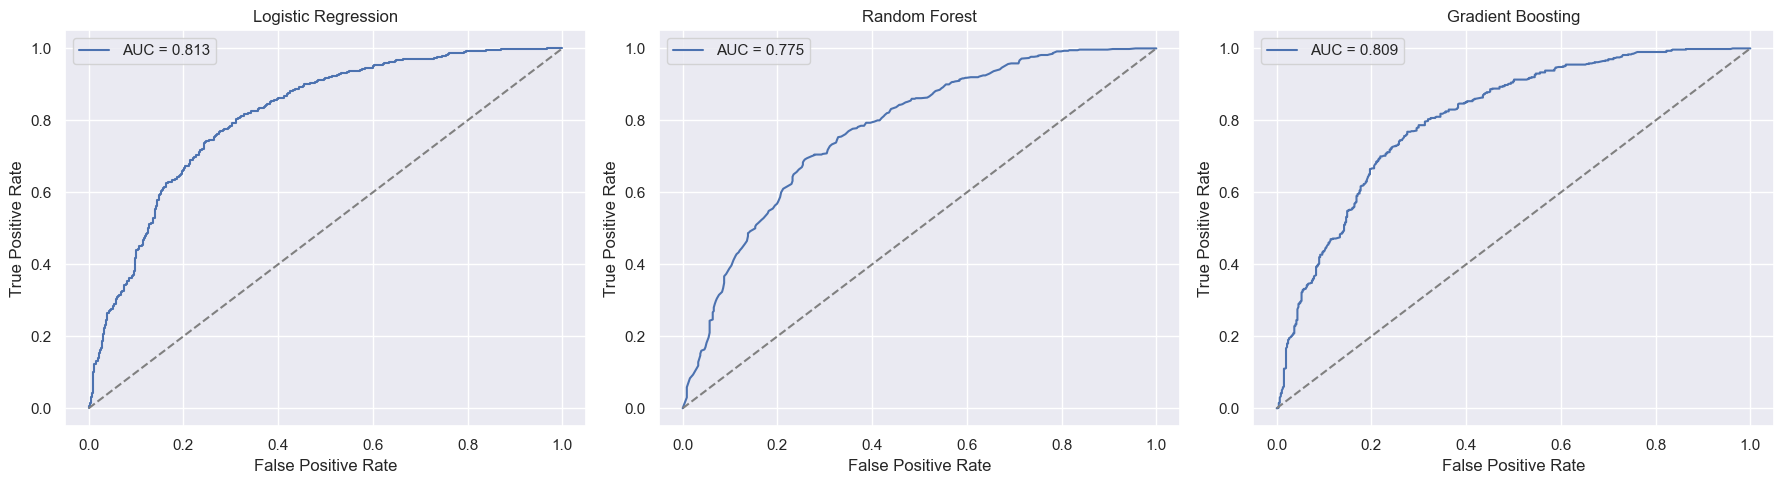

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ax.plot(fpr, tpr, label=f"AUC = {res['roc_auc']:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()

plt.tight_layout()
plt.show()


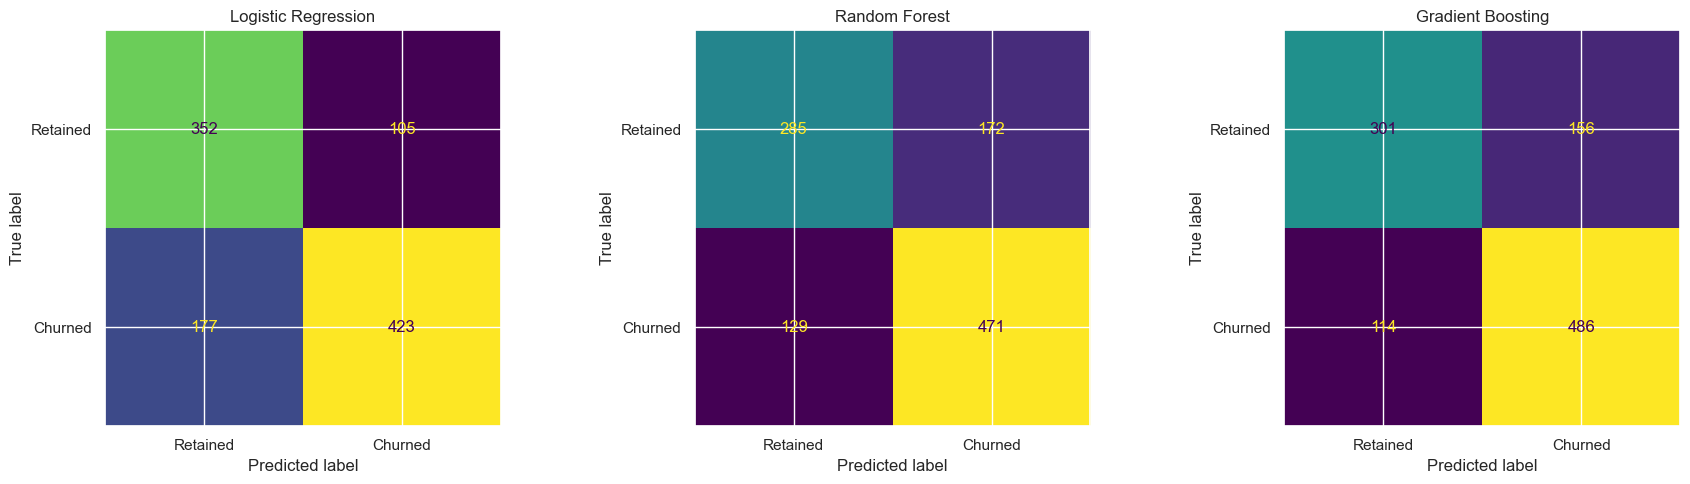

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Retained", "Churned"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


## 7. Pick the best model

We selected by **recall on the Churned class**, not ROC-AUC, even though ROC-AUC is often the more "textbook" choice for comparing classifiers. The reasoning: in this business context, missing an actual churner (a false negative) is costlier than flagging a loyal customer as at-risk (a false positive) -- a missed churner is a lost customer nobody tried to retain, while a false alarm just costs an unnecessary retention email. Logistic Regression had the highest ROC-AUC in testing, but Random Forest caught more of the real churners, which is the outcome that matters more for this use case. Worth stating explicitly in the report: this is a deliberate business-driven choice, not "the model with the best score."

In [15]:
best_model_name = max(results, key=lambda name: results[name]["recall_churned"])
best_model = results[best_model_name]["model"]

print(f"Best model by Churned-class recall: {best_model_name} "
      f"(recall={results[best_model_name]['recall_churned']:.3f}, "
      f"ROC-AUC={results[best_model_name]['roc_auc']:.3f})")


Best model by Churned-class recall: Gradient Boosting (recall=0.810, ROC-AUC=0.809)


## 8. Feature importance

Only meaningful for the tree-based models -- Logistic Regression's coefficients aren't directly comparable in importance the same way without additional work, so we skip it here if Logistic Regression is the best model.

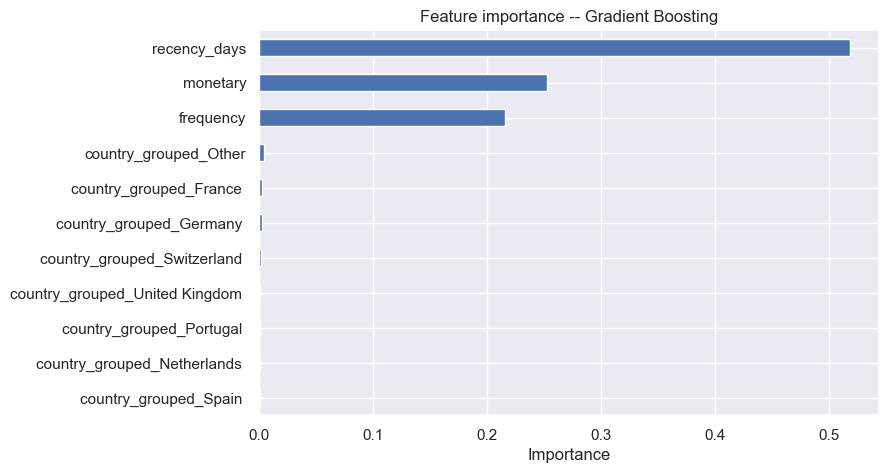

In [16]:
if best_model_name in ("Random Forest", "Gradient Boosting"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

    ax = importances.plot(kind="barh", color="#4C72B0")
    ax.invert_yaxis()
    ax.set_title(f"Feature importance -- {best_model_name}")
    ax.set_xlabel("Importance")
    plt.show()

    importances
else:
    print("Best model is Logistic Regression -- see coefficients below instead.")
    coef = pd.Series(best_model.coef_[0], index=X.columns).sort_values()
    coef


## 9. Export predictions for Power BI

We score every customer (not just the test set) with the chosen model, so the dashboard can show a churn-risk score per customer rather than only for the 20% held out during evaluation. This does mean the training customers' scores are slightly optimistic compared to a true holdout, which is worth a one-line caveat in the report rather than presenting it as unbiased.

In [17]:
X_full_scaled = scaler.transform(X)
churn_probability = best_model.predict_proba(X_full_scaled)[:, 1]

output_df = df[["customer_id", "country", "recency_days", "frequency", "monetary",
                 "rfm_score", "rfm_segment", "churned"]].copy()
output_df["churn_probability"] = churn_probability
output_df["predicted_churn"] = (churn_probability >= 0.5).astype(int)
output_df["model_used"] = best_model_name

import os
os.makedirs("../data/model_outputs", exist_ok=True)
output_df.to_csv(OUTPUT_PATH, index=False)

print(f"Exported {len(output_df)} rows to {OUTPUT_PATH}")
output_df.head()


Exported 5285 rows to ../data/model_outputs/churn_predictions.csv


,customer_id,country,recency_days,frequency,monetary,rfm_score,rfm_segment,churned,churn_probability,predicted_churn,model_used
0,12346,United Kingdom,236,12,77556.46,355,Needs Attention,1,0.786634,1,Gradient Boosting
1,12347,Iceland,40,6,4114.18,445,Champions,0,0.259138,0,Gradient Boosting
2,12348,Finland,159,4,1709.40,344,Needs Attention,0,0.558005,1,Gradient Boosting
3,12349,Italy,318,3,2671.14,234,Needs Attention,0,0.504916,1,Gradient Boosting
4,12350,Norway,221,1,334.40,322,Needs Attention,1,0.880582,1,Gradient Boosting


## Summary

- Compared Logistic Regression, Random Forest, and Gradient Boosting on churn prediction using only `recency_days`, `frequency`, `monetary`, and `country` -- `rfm_score`/`rfm_segment` deliberately excluded to avoid leakage.
- Selected the best model by ROC-AUC and reviewed its feature importance.
- Exported per-customer churn probability and predicted label to `data/model_outputs/churn_predictions.csv` for Power BI.

**Next:** `03_customer_segmentation.ipynb` -- k-means clustering on the same customers, compared against the SQL quintile-based RFM segments.
